In [7]:
from keras.datasets import cifar10

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import tensorflow as tf
import numpy as np

In [15]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from keras import utils

In [ ]:
from sklearn.metrics import accuracy_score
from keras.layers import Dense, Activation, Flatten

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
X_train.shape

(50000, 32, 32, 3)

array([[[154, 177, 187],
        [126, 137, 136],
        [105, 104,  95],
        ...,
        [ 91,  95,  71],
        [ 87,  90,  71],
        [ 79,  81,  70]],

       [[140, 160, 169],
        [145, 153, 154],
        [125, 125, 118],
        ...,
        [ 96,  99,  78],
        [ 77,  80,  62],
        [ 71,  73,  61]],

       [[140, 155, 164],
        [139, 146, 149],
        [115, 115, 112],
        ...,
        [ 79,  82,  64],
        [ 68,  70,  55],
        [ 67,  69,  55]],

       ...,

       [[175, 167, 166],
        [156, 154, 160],
        [154, 160, 170],
        ...,
        [ 42,  34,  36],
        [ 61,  53,  57],
        [ 93,  83,  91]],

       [[165, 154, 128],
        [156, 152, 130],
        [159, 161, 142],
        ...,
        [103,  93,  96],
        [123, 114, 120],
        [131, 121, 131]],

       [[163, 148, 120],
        [158, 148, 122],
        [163, 156, 133],
        ...,
        [143, 133, 139],
        [143, 134, 142],
        [143, 133, 144]]], dtype=uint8)
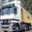

In [9]:
display(X_train[1])

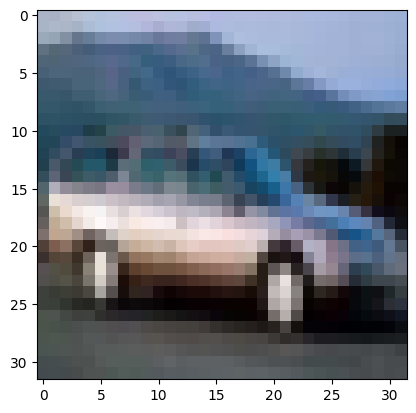

In [ ]:
plt.imshow(X_train[4])#Vemos que tiene forma de auto a pesar del bajo numero de pixeles

In [12]:
#vector de 32x32 pixeles
X_train = X_train.reshape(X_train.shape[0], 32, 32, 3)
X_test = X_test.reshape(X_test.shape[0], 32, 32, 3)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [13]:
#normalizando
X_train /= 255
X_test /= 255

In [14]:
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = utils.to_categorical(y_train, n_classes)
Y_test = utils.to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (50000, 1)
Shape after one-hot encoding:  (50000, 10)


In [ ]:
model = Sequential()
#-------------------------------------PRIMER BLOQUE CONVOLUCIONAL
#32 filtros de 3x3 padding='same' mantiene tamaño 32x32
#ReLU introduce no linealidad
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
# BatchNormalization estabiliza el entrenamiento y Hace que el modelo converja más rápido
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))# reduce tamaño 32x32 → 16x16
#Dropout apaga 25% de neuronas aleatoriamente
#Reduce overfitting
model.add(Dropout(0.25))
#-------------------------------------
#-------------------------------------SEGUNDO BLOQUE CONVOLUCIONAL
#Ahora aumentamos filtros (32 → 64) (Más filtros = aprende patrones más complejos)
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))#Reduce tamaño (16x16 → 8x8)
model.add(Dropout(0.25))
#-------------------------------------
#-------------------------------------
#Convierte mapas 3D en vector 1D
model.add(Flatten())
#Capa densa grande para aprender combinaciones complejas
model.add(Dense(128, activation='relu'))
#Dropout más fuerte aquí (50%) porque esta capa tiene MUCHOS parámetros
model.add(Dropout(0.5))
#Capa final: 10 neuronas (porque CIFAR-10 tiene 10 clases)
model.add(Dense(10, activation='softmax'))#Softmax convierte a probabilidades

In [22]:
#Entrenamiento del modelo
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
model.fit(X_train, Y_train, batch_size=128, epochs=20, validation_data=(X_test, Y_test))#aumentamos los epochs para tener mayor tiempo de aprendizaje

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 334ms/step - accuracy: 0.6667 - loss: 0.9585 - val_accuracy: 0.6876 - val_loss: 0.8968
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.6752 - loss: 0.9239 - val_accuracy: 0.6859 - val_loss: 0.8982
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 137s 329ms/step - accuracy: 0.6825 - loss: 0.9098 - val_accuracy: 0.6775 - val_loss: 0.9319
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 143s 333ms/step - accuracy: 0.6898 - loss: 0.8883 - val_accuracy: 0.6783 - val_loss: 1.0129
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 127s 326ms/step - accuracy: 0.7034 - loss: 0.8634 - val_accuracy: 0.7116 - val_loss: 0.8347
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 132s 338ms/step - accuracy: 0.7065 - loss: 0.8318 - val_accuracy: 0.6950 - val_loss: 0.8769
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 342ms/step - accuracy: 0.7144 - loss: 0.8207 - val_accuracy: 0.6581 - val_loss: 1.1401
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 139s 333ms/step - accuracy: 0.7200 -

In [ ]:
#Evaluamos el modelo
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print("Precision del modelo:", acc)#vemos un accuracy del 0.72
print("loss:", loss)

Precision del modelo: 0.7246000170707703
loss: 0.88579922914505


In [24]:
#Si tenemos 65% de precision del modelo, deberia ser lo suficientemente bueno para hacer la siguiente prediccion
idx = 5  #tomamos cualquier imagen del conjunto de prueba
img = X_test[idx]
true_label = np.argmax(Y_test[idx])

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [28]:
pred = model.predict(img.reshape(1,32,32,3))
pred_label = np.argmax(pred)#hacemos la prediccion nuestro modelito

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


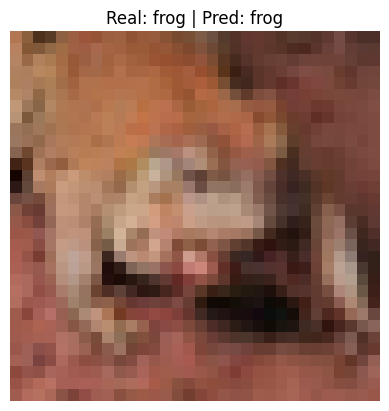

In [29]:
plt.imshow(img)
plt.title(f"Real: {class_names[true_label]} | Pred: {class_names[pred_label]}")
plt.axis("off")
plt.show()